You are given an integer array heights where heights[i] represents the height of the ith bar.

You may choose any two bars to form a container. Return the maximum amount of water a container can store.

Example 1:

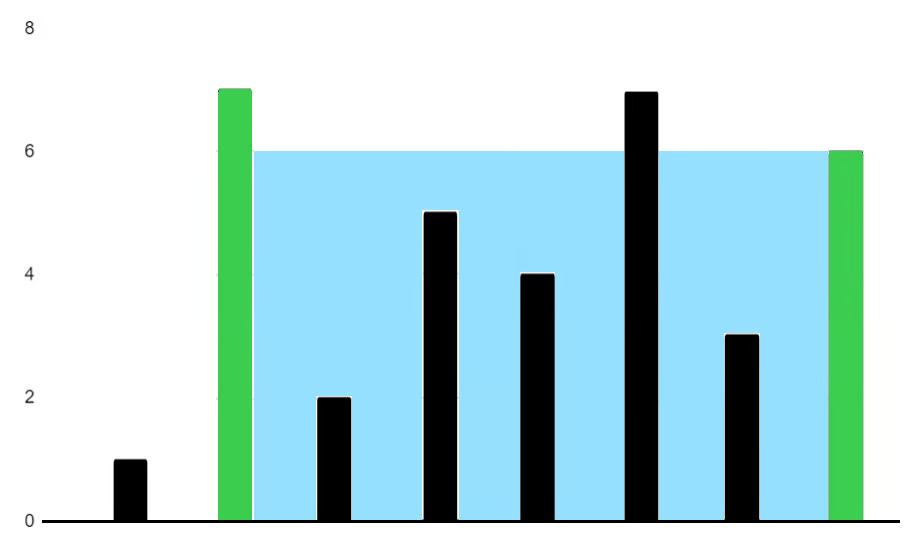

Input: height = [1,7,2,5,4,7,3,6]

Output: 36

Example 2:

Input: height = [2,2,2]

Output: 4

Constraints:

2 <= height.length <= 1000

0 <= height[i] <= 1000


In [ ]:
from typing import List

# Brute Force

Intuition

We try every possible pair of lines and compute the area they form.

For each pair (i, j), the height of the container is the shorter of the two lines, and the width is the distance between them.

By checking all pairs, we are guaranteed to find the maximum area.

Algorithm

Initialize res = 0 to track the maximum area found.

Use two nested loops:

Outer loop picks the left line i.

Inner loop picks the right line j > i.

For each pair (i, j):

Compute the height as min(heights[i], heights[j]).

Compute the width as j - i.

Update res with the maximum of its current value and the new area.

After checking all pairs, return res.

In [ ]:
# Brute Force
# Time Complexity: O(n^2)
# Space Complexity: O(1)
class Solution:
    def maxArea(self, heights: List[int]) -> int:
        res = 0
        for i in range(len(heights)):
            for j in range(i + 1, len(heights)):
                res = max(res, min(heights[i], heights[j]) * (j - i))
        return res

# Two Pointers

Intuition

Using two pointers lets us efficiently search for the maximum area without checking every pair.

We start with the widest container (left at start, right at end).

The height is limited by the shorter line, so to potentially increase the area, we must move the pointer at the shorter line inward.

Moving the taller line never helps because it keeps the height the same but reduces the width.

By always moving the shorter side, we explore all meaningful possibilities.

Algorithm

Initialize two pointers:

l = 0

r = len(heights) - 1

Set res = 0 to store the maximum area.

While l < r:

Compute the current area:

area = min(heights[l], heights[r]) * (r - l)

Update res with the maximum area so far.

Move the pointer at the shorter height:

If heights[l] <= heights[r], move l right.

Otherwise, move r left.

Return res after the pointers meet.

In [ ]:
# Two Pointers
# Time Complexity: O(n)
# Space Complexity: O(1)
class Solution:
    def maxArea(self, heights: List[int]) -> int:
        l, r = 0, len(heights) - 1
        max_area = 0

        while l < r:
            height = min(heights[l], heights[r])
            width = r - l
            max_area = max(max_area, height * width)

            if heights[l] < heights[r]:
                l += 1
            else:
                r -= 1

        return max_area